# Bending StyleGAN 

In this notebook, we'll see how to bend existing StyleGAN models with the `torchbend` package. `torchbend` uses its own StyleGAN repository, because it implements custom operations (defined in `torch_utils/ops`) that needed to be implemented as `torch.ops` to be tracable by the `torchbend` tracing functionalities.


First, execute the cell below to download a model to the `torchbend/models/stylegan" directory.

In [1]:
import sys, re, os
import urllib
from pathlib import Path

torchbend_dir = Path(os.getcwd()).parent / ".." 
os.environ['TORCHBEND_DEFAULT_MODEL_DIR'] = str(torchbend_dir / "models")
models_dir = torchbend_dir / "models" / "stylegan3" 
os.makedirs(models_dir, exist_ok=True)
sys.path.append(str(torchbend_dir.resolve()))


import torchbend as tb
tb.set_output('notebook')

# download the model from website
model_path = "https://api.ngc.nvidia.com/v2/models/org/nvidia/team/research/stylegan3/1/files?redirect=true&path=stylegan3-r-ffhqu-256x256.pkl"


## Understanding StyleGAN models

In the `torchbend` philosophy, there is two distinct levels corresponding to different layers of interface : 
- `BendedModule` is the main object, taking a `nn.Module` subclass and implementing all the tracing / bending operations
- `BendedInterface` is a higher-level object, that implements how concrete models (here, StyleGAN) should be traced, gathered if separated in several modules, diminishes the code boilerplate, and implements several model-specific helper functions.

The provided interface for StyleGAN, `BendedStyleGAN`, automatically loads the checkpoint, traces the generation function and mark the most important computation steps (we'll investigate that below). It takes an additional arguments, indicating if the model is a StyleGAN2 model or a StyleGAN3 (if left to none, the interface tries to automatically fetch the information from the filename.) The original generator is held in the `original_model` property, while `model` corresponds to the underlying `BendedModule` object.

**Important** do not forget to adjust the device in the cell below to your own environement!

In [2]:
import torch
from torchbend.interfaces.stylegan import BendedStyleGAN

# IMPORTANT change the device 
device = torch.device('cuda:0')

# import the checkpoint using the provided torchbend interface
bended = BendedStyleGAN(model_path, device=device)
print("model attribute : ", bended.model)
print("original_model attribute : ", type(bended.original_model))

Setting up PyTorch plugin "bias_act_plugin"... 

/u/repmus/chemla/miniconda3/envs/torchbend/lib/python3.11/site-packages/torch/utils/cpp_extension.py:2356: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


Done.
Setting up PyTorch plugin "filtered_lrelu_plugin"... 

/u/repmus/chemla/miniconda3/envs/torchbend/lib/python3.11/site-packages/torch/utils/cpp_extension.py:2356: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


Done.
model attribute :  BendedModule(Generator)
original_model attribute :  <class 'torch_utils.persistence.persistent_class.<locals>.Decorator'>



A StyleGAN model consists in : 
- a `generator`, that takes random variables (called the latent space, `z`,), and optionally the class label, `c`, and generates the image. 
- a `discriminator`, that is trained to discriminate between real images and generated images. 

The training process is then based on a zero-sum game, where the generators trains to fool the discriminator. Here we will focus on the generator, as the discriminator is not directly used for the generation. 

The inner structure of the StyleGAN3 generator is not *exactly* feed-forward like regular GANs. In the generator, both latent variables and class variables are first fed into a network, called `MappingNetwork`. Class variables, that are discrete values (class 1, class 2...) are also first projected in a continuous space, called an `embedding`, and concatenated to the latent values. This mapping network will generate activation for each of layer of the generator, such that each layer *l+1* will take not only the output of the previous layer *l*, and this intermediary representation *w[l+1]*, to generate the next result. This structure is not simply a *convolution* network but a *modulated convolution* network : the convolution kernel is not fixed, but modulated by this intermerdiary representation. 

Understanding this particularity will be important because it impacts which activation, or weight, we will target. We can access the number of layers of our generator through the *n_layers* property : 

In [3]:
print("number of layers : ", bended.n_layers)


number of layers :  14


## Bending a StyleGAN model : how and why

Ok, let's bend our model now. *Bending* a neural network means : hijacking the inner structure of a neural network to modify its inner working, and hence the obtained generations. However, there are many ways to do it, that are not exactly the same. For example, we can distinguish : 

- *weight bending* : altering the weights of a module
- *activation bending* : altering the intermediate results of a module

The *weights* of a module is the set of parameters that are learned during training, used during the processing of the inputs but shared across every generation : i.e. the kernels of a convolution module. It somehow represents the *state* of your neural network, saved in the *.ckpt* file you downloaded above, and singluar for each individual training. 

The *activations* are the set of intermediate values computed by a complex machine learning model during the full generation process. An important difference with weights is that these activations depend on the input you're providing, as they are intermediary computations obtained from a given set of inputs. Activation bending is generally more powerful and expressive, but also more difficult to obtain in terms of code (but no worries, it's working here!)

### Weight bending

Let's bend the weights of our model. We can print all the weights of our model using the `weight` names callback : 


In [4]:

bended.print_weights()

name,shape,dtype,min,max,mean,stddev
synthesis.input.weight,"(1024, 1024)",torch.float32,-24.419140,23.910730,-0.000325,3.371275
synthesis.input.affine.weight,"(4, 512)",torch.float32,-6.533479,5.932352,0.045524,1.450401
synthesis.input.affine.bias,"(4,)",torch.float32,-0.677979,2.761899,0.460904,1.561449
synthesis.L0_36_1024.weight,"(1024, 1024, 1, 1)",torch.float32,-24.730854,20.630592,0.001788,1.744107
synthesis.L0_36_1024.bias,"(1024,)",torch.float32,-1.070917,5.132575,0.479948,0.709617
synthesis.L0_36_1024.affine.weight,"(1024, 512)",torch.float32,-11.310317,9.802192,0.025567,1.713646
synthesis.L0_36_1024.affine.bias,"(1024,)",torch.float32,-0.156982,1.914143,0.966212,0.310105
synthesis.L1_36_1024.weight,"(1024, 1024, 1, 1)",torch.float32,-19.491272,20.062233,0.009338,1.762745
synthesis.L1_36_1024.bias,"(1024,)",torch.float32,-2.189486,3.505654,0.383440,0.832466
synthesis.L1_36_1024.affine.weight,"(1024, 512)",torch.float32,-11.086507,10.821275,0.199621,1.757808


'name                                 shape                           dtype                  min         max          mean     stddev\n-----------------------------------  ------------------------------  -------------  -----------  ----------  ------------  ---------\nsynthesis.input.weight               torch.Size([1024, 1024])        torch.float32   -24.4191     23.9107    -0.000324895   3.37128\nsynthesis.input.affine.weight        torch.Size([4, 512])            torch.float32    -6.53348     5.93235    0.045524      1.4504\nsynthesis.input.affine.bias          torch.Size([4])                 torch.float32    -0.677979    2.7619     0.460904      1.56145\nsynthesis.L0_36_1024.weight          torch.Size([1024, 1024, 1, 1])  torch.float32   -24.7309     20.6306     0.00178764    1.74411\nsynthesis.L0_36_1024.bias            torch.Size([1024])              torch.float32    -1.07092     5.13258    0.479948      0.709617\nsynthesis.L0_36_1024.affine.weight   torch.Size([1024, 512])      

Here, the names are quite self explicit : the weights with the *mapping.* prefix are the weights of the mapping network, while the *synthesis.* prefix are the weights of the synthesis network. 
For the synthesis network, the names are labeled logically : the layer index number, the dimensionality of the activation, and the number of channels. For example, the `synthesis.L13_256_128.affine.weight` means that this is the weight of the 14th layer, that has 256x256 resolution and 128 channels. Here, each layer has 4 different parameters, instead of two for a regular convolutio operation. This is because StyleGAN2 & 3 uses **modulated** convolution, instead of a normal one. Indeed, a regular convolution has two different parameters : 

$$ \mathbf{y} =  \mathbf{x} \star \mathbf{k} + \mathbf{b}$$

where $ \star $ is the convolution operation, $ \mathbf{x} $ the input activation (of size $channel_{in} \times width \times height$),  $ \mathbf{y} $ the output activation (of size $channel_{in} \times width \times height$), and $\mathbf{k}$ a fixed weight (of size $channel_{out} \times channel_{in} \times kernel_w \times kernel_h$). 

In a deep convolution network, several layers of such convolution units are proceeded, the output of each layer given as input for the next layer. In a modulated convolution, the convolution kernel is modulated by an additional input, noted here $\mathbf{w}$, to make the convolution operation adaptive to a set of additional input (here, the intermerdiary representations).

$$ \mathbf{y} =  \mathbf{x} \star (\mathbf{k} \odot f(\mathbf{w}))  + \mathbf{b}$$

Here, $f(\mathbf{w})$ is an affine transform, providing a weight matrix of $channel_{in}$ values that are used to re-scale each channel of the incoming activation. This is designed to add some expressivity to the synthesis network, and that information from the inputs is injected at every level of the generation. Hence, we can understand the weight names : 

- `weight` : the unmodulated convolution kernel of the layer
- `bias`: the unmodulated convolution bias of the layer
- `affine.weight`: the weight of the affine transform applied to $\mathbf{w}$
- `affine.bias` : the bias of the affine transform applied to $\mathbf{w}$

### Bending activations

Activations are "hidden" values that are computed during generation, and are hence more difficult to retrieve, and even more difficult to bend. Indeed, bending the weights can be done by loading the `.ckpt` file we downloaded, and modifying the `state_dict` before loading. For activations, such an approach would ask to re-write the original code, and saving somewhere the intermediary values, and this is very difficult most of the times because it acts against how the code is designed. 

Hopefully, there is an alternative : *tracing*. Tracing means providing a fake input to the module, registering all the operations done to this input, and "re-writing" a bendable version of the process. While this is very modular, allowing to recombine all the computing graph for our bending purpose, it imples that the code is *tracable*, and this is quite technical. Furthermore, it kind of "print" the computational graph, and this can have strong side effects if some parts of the code depends on the value of the input. 

Interfaces are made to make this tracing operation implicit, so you don't take care of it. For exemple, we can print all the activations of our model : 

In [5]:
bended.print_activations()

name,op,target,shape,args,kwargs
z,placeholder,z,"(4, 512)",(),{}
c,placeholder,c,None,(),{}
truncation_psi,placeholder,truncation_psi,None,"(1,)",{}
truncation_cutoff,placeholder,truncation_cutoff,None,"(None,)",{}
update_emas,placeholder,update_emas,None,"(False,)",{}
pow_1,call_function,aten.pow.Tensor_Scalar,"(4, 512)","(z, 2)",{}
mean,call_function,aten.mean.dim,"(4, 1)","(pow_1, [1], True)",{}
add,call_function,aten.add.Tensor,"(4, 1)","(mean, 1e-08)",{}
rsqrt,call_function,aten.rsqrt.default,"(4, 1)","(add,)",{}
mul,call_function,aten.mul.Tensor,"(4, 512)","(z, rsqrt)",{}


"-----------------------------------  -------------  -----------------------------------  ---------------------  ------------------------------------------------------------------------------------------------------------------------------------------------------------  -------------------------------------------------------------\nz                                    placeholder    z                                    (4, 512)               ()                                                                                                                                                            {}\nc                                    placeholder    c                                                           ()                                                                                                                                                            {}\ntruncation_psi                       placeholder    truncation_psi                                              (1,)  

Ooch, this is way too many values. Indeed, tracing records **everything**, even the simplest operations that we don't really care about. Fortunately, `torchbend` implements a `mark` function that allows to register, in the original code, the most interesting activations to retrieve. These activations can be accessed with the `aliases` callback : 

In [6]:
aliases = bended.aliases()
n_layers = bended.n_layers
for i in range(n_layers):
    print("layer %d : "%i, end="")
    print("mapping shape", bended.activation_shape(aliases['mapping'][i]), end="; ")
    print("layer shape", bended.activation_shape(aliases['layer_out'][i]), end="; ")
    if i > 0: print("style shape", bended.activation_shape(aliases['styles'][i]), end="") # the first layer is the model's input and is not modulated
    print()
    

layer 0 : mapping shape [4, 512]; layer shape [4, 1024, 36, 36]; 
layer 1 : mapping shape [4, 512]; layer shape [4, 1024, 36, 36]; style shape [4, 1024]
layer 2 : mapping shape [4, 512]; layer shape [4, 1024, 36, 36]; style shape [4, 1024]
layer 3 : mapping shape [4, 512]; layer shape [4, 1024, 36, 36]; style shape [4, 1024]
layer 4 : mapping shape [4, 512]; layer shape [4, 1024, 52, 52]; style shape [4, 1024]
layer 5 : mapping shape [4, 512]; layer shape [4, 1024, 52, 52]; style shape [4, 1024]
layer 6 : mapping shape [4, 512]; layer shape [4, 1024, 84, 84]; style shape [4, 1024]
layer 7 : mapping shape [4, 512]; layer shape [4, 1024, 84, 84]; style shape [4, 1024]
layer 8 : mapping shape [4, 512]; layer shape [4, 724, 148, 148]; style shape [4, 724]
layer 9 : mapping shape [4, 512]; layer shape [4, 512, 148, 148]; style shape [4, 512]
layer 10 : mapping shape [4, 512]; layer shape [4, 362, 148, 148]; style shape [4, 362]
layer 11 : mapping shape [4, 512]; layer shape [4, 256, 276, 27

such that we can see that we marked the given mapping $\mathbf{w}$, the style vectors (the output of the linear transforms modulating the kernels), and the output of each layer, for each indivudual layer. We can now, for example, retrieve individually all the layers intermediary values with the `get_activations` callback : 

torch.Size([4, 256, 276, 276])


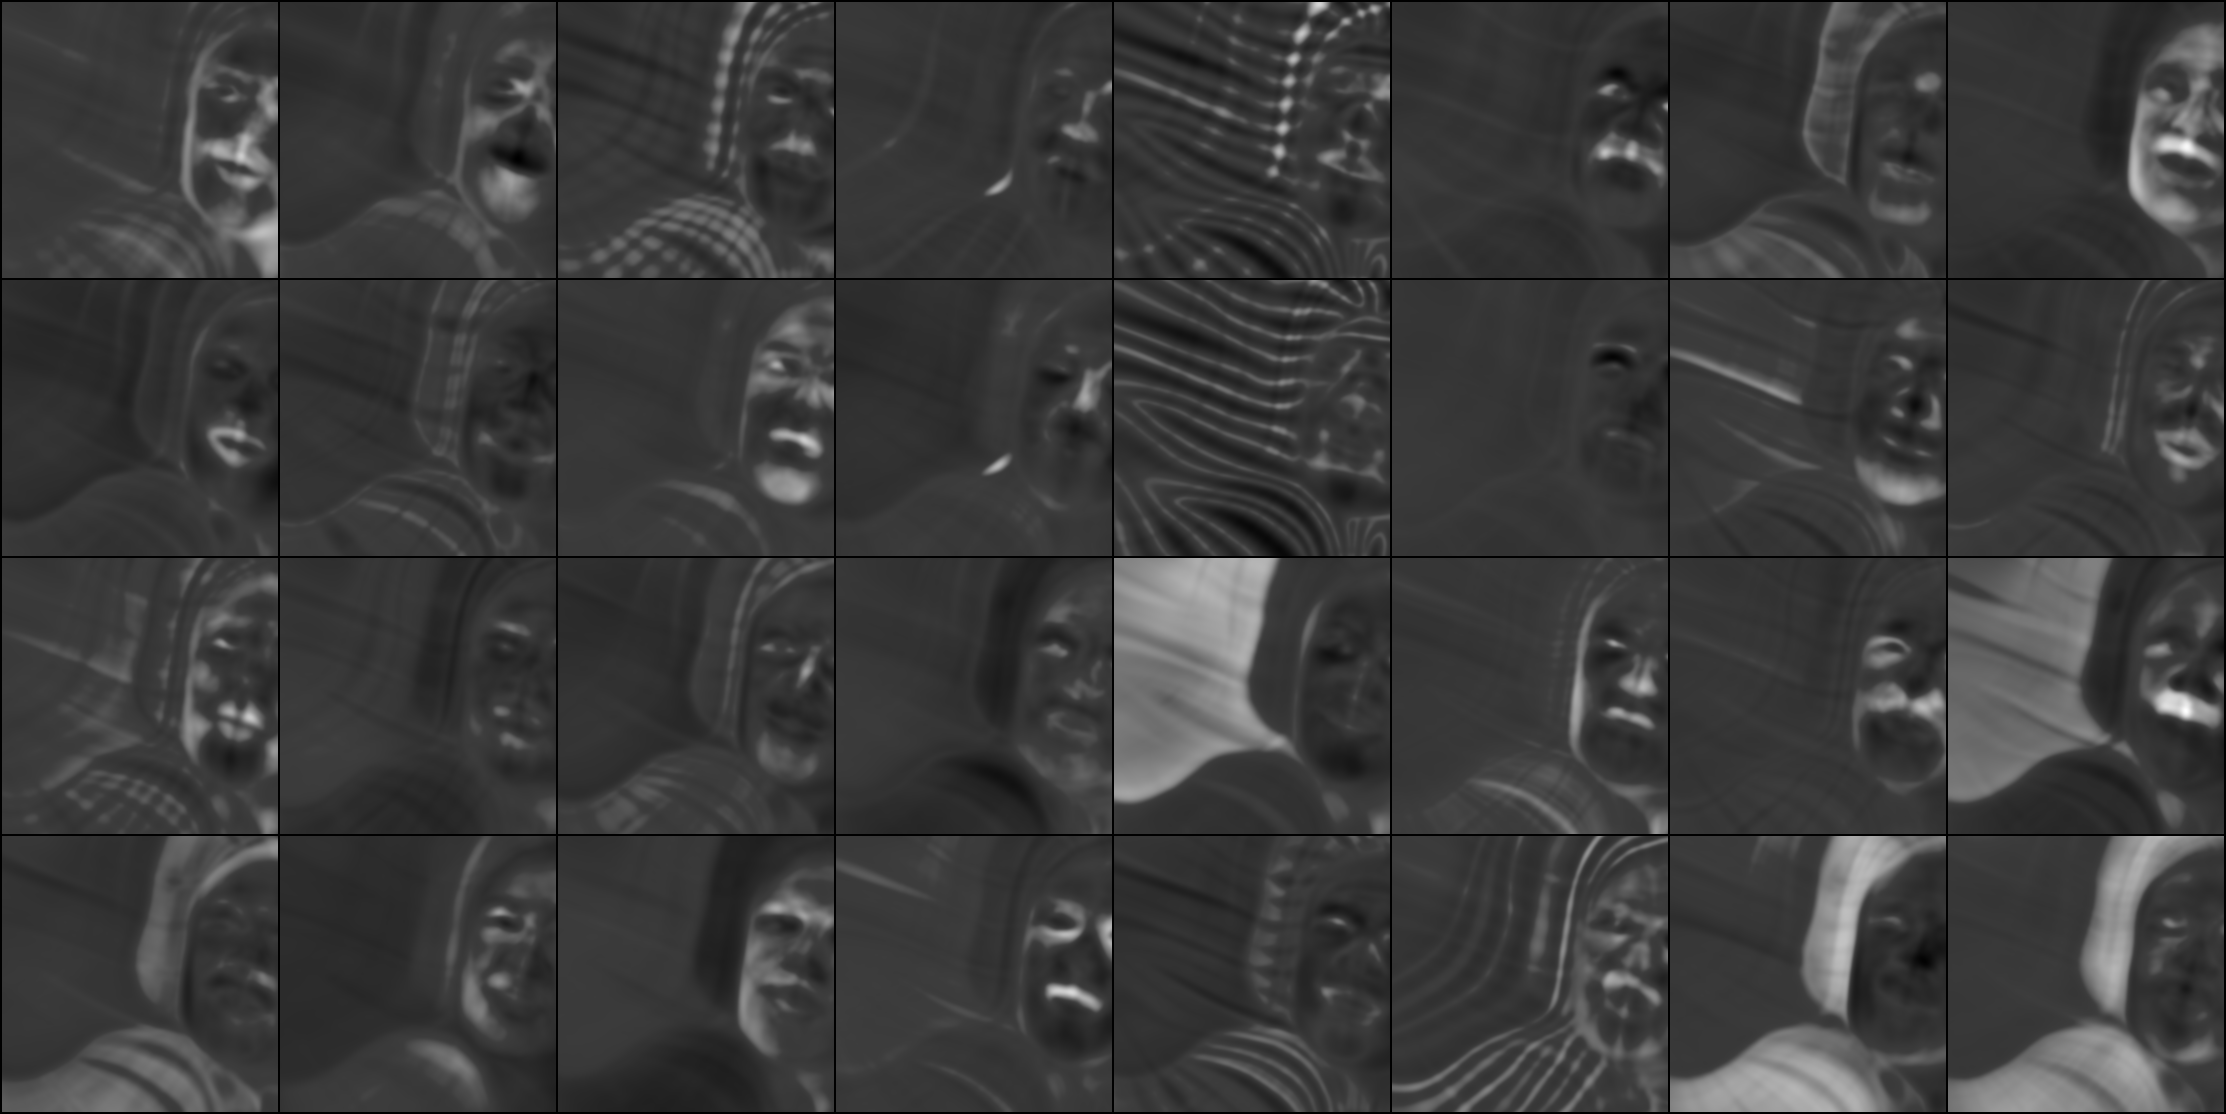

In [7]:
from IPython.display import Image, display


# CHANGE THE LAYER IDX JUST BELOW
layer_idx = 11
activation_name = aliases['layer_out'][layer_idx]

inputs = bended.get_inputs(4)
activation = bended.get_activations(activation_name, **inputs)[activation_name]

print(activation.shape)

# plot the 16th first channels of the first image
import torchvision
from torchvision.utils import make_grid
from torchbend.ui.utils import tensor_to_image
out_plot = make_grid(activation[0][:32][:, None], normalize=True)

tensor_to_image(out_plot, './image.png')
display(Image('image.png'))

If you tried out several values for the `layer_idx` value, you can see that smaller layer indexes are smaller and more abstract, and that higher layer indexes have higher dimensions and closer to the final image. This is because StyleGAN, at each layer, upsamples the generated image, while diminishing the amount of channels. Hence, we can postulate that bending higher levels of representation (first computation layers, closer to inputs) will have a "broader“ impact on the generation, while bending lower levels or representation (last computation layers, closer to data) will provoke more "local" changes to the image structure. Let's try that out in the accompanying notebooks! 